In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# Load Excel file
df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")
# Display first 5 rows
print(df.head())
# Display dataset information
print(df.info())
# Display summary statistics
print(df.describe())
# Check missing values
print(df.isnull().sum())
# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
# Create Month column
df["Month"] = df["Order_Date"].dt.month_name()
# Calculate Total Sales
total_sales = df["Total_Sales"].sum()
print("Total Sales:", total_sales)

    Order_ID  Order_Date Customer_ID Customer_Name   Age  Gender       City  \
0  ORD100002  2025-02-25    CUST5529  Customer_227  30.0  Female  Bengaluru   
1  ORD100003  2025-10-14    CUST3127  Customer_182  63.0    Male  Bengaluru   
2  ORD100004  2025-05-13    CUST8887  Customer_487  62.0  Female  Bengaluru   
3  ORD100005  2025-12-02    CUST2515  Customer_470  65.0  Female    Kolkata   
4  ORD100006  2025-11-20    CUST4796  Customer_380  44.0    Male  Bengaluru   

  Product     Category  Quantity  Unit_Price  Total_Sales  
0    Rice      Grocery         7     2829.77     19808.39  
1    Book    Education         5    27906.16    139530.80  
2    Book    Education         8    37491.06    299928.48  
3  Mobile  Electronics         9    28541.36    256872.24  
4    Rice      Grocery        10    14036.59    140365.90  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------    

===== KPI SUMMARY =====
Total Sales : 139399439.65
Total Orders: 992


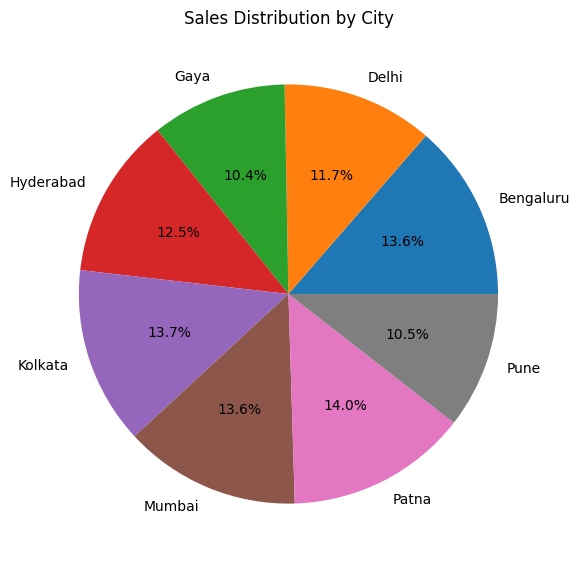

In [2]:
# KPI CALCULATIONS

total_sales = df['Total_Sales'].sum()
total_orders = df['Order_ID'].nunique()
print("===== KPI SUMMARY =====")
print("Total Sales :", total_sales)
print("Total Orders:", total_orders)

# SALES BY CITY (PIE CHART)
city_sales = df.groupby('City')['Total_Sales'].sum()
plt.figure(figsize=(6,6))
city_sales.plot(
    kind='pie',
    autopct='%1.1f%%')
plt.title("Sales Distribution by City")
plt.ylabel("")
plt.tight_layout()
plt.show()



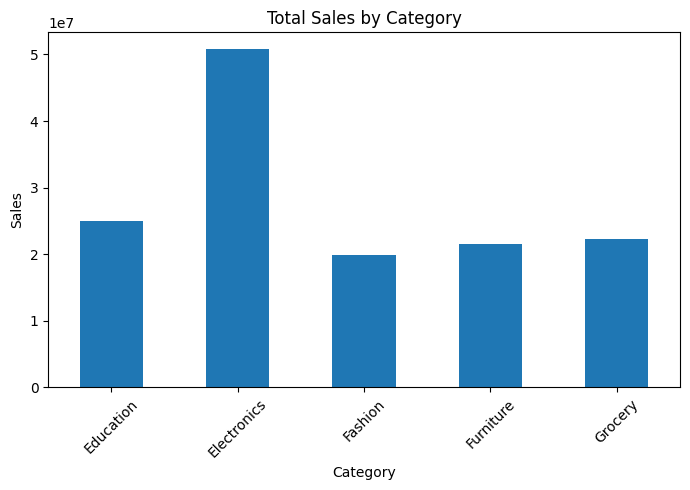

In [3]:
# SALES BY CATEGORY
category_sales = df.groupby('Category')['Total_Sales'].sum()
plt.figure(figsize=(7,5))
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


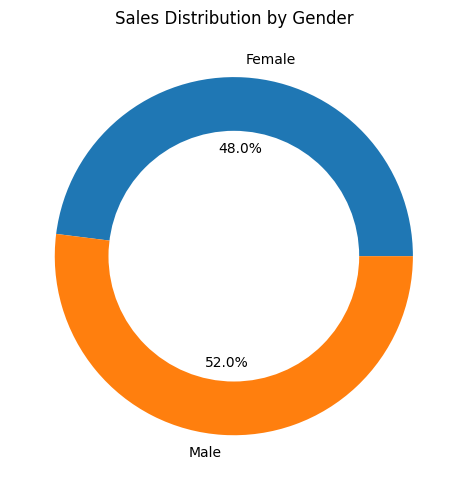

In [4]:
# SALES BY GENDER (DONUT CHART)
gender_sales = df.groupby('Gender')['Total_Sales'].sum()
plt.figure(figsize=(5,5))
plt.pie(
    gender_sales,
    labels=gender_sales.index,
    autopct='%1.1f%%')
# Donut Hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Sales Distribution by Gender")
plt.tight_layout()
plt.show()


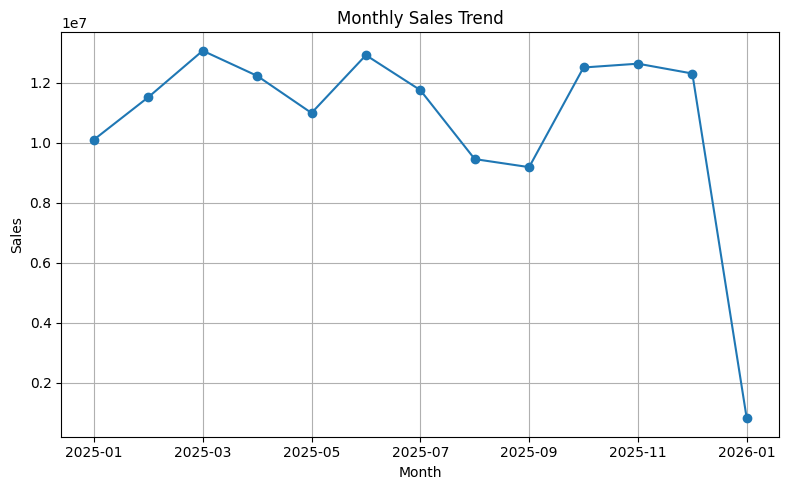

In [5]:
# MONTHLY SALES TREND
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
monthly_sales = df.groupby(
    df['Order_Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str)
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()
